# Prediction of Two-Phase Flow Rate Through Wellhead Chokes

This notebook develops a machine-learning approach for predicting gross liquid rate (Ql) through wellhead chokes in oil wells.

The objective is to estimate liquid production from wellhead and choke measurements. The analysis follows the project methodology from data preparation and exploratory analysis through feature engineering, empirical correlation, regression-model comparison, model selection, hyperparameter tuning, diagnostics, and field-level analysis.

A fixed random seed of 42 is used throughout the analysis.

# Project methodology

The analysis follows this sequence:

1. Data loading and audit
2. Exploratory data analysis
3. Data cleaning and 3σ outlier filtering
4. Feature engineering
5. Data splitting and scaling
6. Gilbert baseline
7. Comparison of ten regression models
8. Comparison of alternative feature sets
9. Cross-validation and selection of the top three models
10. Extra Trees hyperparameter tuning
11. Model diagnostics
12. Field-level analysis

The original CS229 dataset is used when `RawData.xlsx` with the expected `All_OL` structure is available. Otherwise, the public Sorush wellhead-choke dataset is used as a separate experimental dataset.

# Methodological scope

The implementation follows the project specification and evaluates the effect of pressure-related features, different regression models, and model-selection procedures. Results are reported for the dataset actually loaded by the notebook.

In [ ]:
# 1. SETUP
import sys, os, re, math, json, warnings, subprocess, importlib, urllib.request
from pathlib import Path

packages = {
    "numpy":"numpy", "pandas":"pandas", "matplotlib":"matplotlib",
    "seaborn":"seaborn", "sklearn":"scikit-learn",
    "openpyxl":"openpyxl", "requests":"requests", "joblib":"joblib"
}
for module, package in packages.items():
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd() / "wellhead_choke_phase1_12_project"
for name in ["data","figures","results","models","src","report"]:
    (ROOT/name).mkdir(parents=True, exist_ok=True)

print("Project directory:", ROOT)
print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Project directory: /content/wellhead_choke_phase1_12_project
Python: 3.13.16
Seed: 42


# 2. Data loading

The notebook first searches for the original `RawData.xlsx` dataset and verifies the expected `All_OL` structure.

If the original dataset is not available, the public Sorush wellhead-choke dataset is loaded. The workbook is inspected to identify the worksheet and header containing the required measurement table.

In [ ]:
# 2. ROBUST DATA LOADER
def norm(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).strip().lower())

def clean_columns(df):
    df = df.copy()
    # Drop columns that are completely empty
    df = df.dropna(axis=1, how="all")
    # Remove Excel-generated blank columns
    keep = [c for c in df.columns if not str(c).strip().lower().startswith("unnamed")]
    df = df.loc[:, keep]
    # Drop completely blank rows
    df = df.dropna(axis=0, how="all")
    return df.reset_index(drop=True)

def find_header_row(raw_sheet, required_aliases, max_rows=50):
    scan = raw_sheet.iloc[:max_rows].copy()
    best_row, best_score, best_hits = None, -1, {}
    for r in range(len(scan)):
        vals = [norm(v) for v in scan.iloc[r].tolist()]
        hits = {}
        for canonical, aliases in required_aliases.items():
            aliases_n = [norm(a) for a in aliases]
            hit = None
            for j, v in enumerate(vals):
                if v in aliases_n:
                    hit = j
                    break
            hits[canonical] = hit
        score = sum(v is not None for v in hits.values())
        if score > best_score:
            best_row, best_score, best_hits = r, score, hits
    return best_row, best_score, best_hits

def load_sheet_with_detected_header(path, sheet_name, required_aliases):
    raw_sheet = pd.read_excel(path, sheet_name=sheet_name, header=None)
    header_row, score, hits = find_header_row(raw_sheet, required_aliases)
    if header_row is None or score < len(required_aliases):
        return None, {"header_row":header_row, "score":score, "hits":hits}
    df = pd.read_excel(path, sheet_name=sheet_name, header=header_row)
    df = clean_columns(df)
    return df, {"header_row":header_row, "score":score, "hits":hits}

def audit_workbook(path, required_aliases, preferred_sheet=None):
    xl = pd.ExcelFile(path)
    rows=[]
    best=None
    for sh in xl.sheet_names:
        raw_sheet=pd.read_excel(path,sheet_name=sh,header=None,nrows=50)
        hr,score,hits=find_header_row(raw_sheet,required_aliases)
        rows.append({
            "sheet":sh,"detected_header_row":hr,"required_fields_found":score,
            "required_fields_total":len(required_aliases)
        })
        if score==len(required_aliases):
            preference = 1 if preferred_sheet and sh.strip().lower()==preferred_sheet.strip().lower() else 0
            candidate=(preference, score, sh)
            if best is None or candidate>best[0]:
                best=(candidate,sh,hr,hits)
    return xl.sheet_names,pd.DataFrame(rows),best

ORIGINAL_ALIASES = {
    "Group":["Group"], "Gross":["Gross"], "Oil":["Oil"], "Water":["Water"],
    "waterCut":["waterCut","water cut"], "GOR":["GOR"], "GLR":["GLR"],
    "FWHP":["FWHP"], "Press":["Press"], "Temp":["Temp"],
    "chokeSize":["chokeSize","choke size"], "CHK_US":["CHK_US"], "CHK_DS":["CHK_DS"]
}
REPLACEMENT_ALIASES = {
    "D64":["D64","D(1/64) in","D(1/64)in","choke size","chokesize"],
    "Pwh":["Pwh","P(psi)","Pwh(psi)","PWH"],
    "GLR":["GLR","GLR(SCF/D)","GLR(SCF/D)"],
    "QL":["QL","Qliq","Qliq,exp(STB/D)","Qliq exp (STB/D)","liquid rate"]
}

original_candidates=[
    Path("RawData.xlsx"), Path("/mnt/data/RawData.xlsx"),
    ROOT/"data"/"RawData.xlsx"
]
orig=None
for p in original_candidates:
    if p.exists():
        try:
            sheets,aud,best=audit_workbook(p,ORIGINAL_ALIASES)
            if best is not None:
                df0,info=load_sheet_with_detected_header(p,best[1],ORIGINAL_ALIASES)
                if df0 is not None:
                    orig=(p,best[1],df0,info,aud)
                    break
        except Exception:
            pass

if orig is not None:
    orig_path,orig_sheet,raw,load_info,workbook_audit=orig
    DATA_MODE="ORIGINAL_CS229"
    print("✓ ORIGINAL CS229 DATA FOUND")
    print("File:",orig_path)
    print("Sheet:",orig_sheet)
    print("Shape:",raw.shape)
else:
    DATA_MODE="PUBLIC_REPLACEMENT"
    print("Original RawData.xlsx was not found.")
    print("Using the documented public Sorush replacement dataset.")

    url="https://media.springernature.com/original/springer-static/esm/art%3A10.1007%2Fs13202-021-01087-4/MediaObjects/13202_2021_1087_MOESM1_ESM.xlsx"
    dest=ROOT/"data"/"Sorush_7245_public.xlsx"
    if not dest.exists():
        try:
            r=requests.get(url,timeout=90)
            r.raise_for_status()
            dest.write_bytes(r.content)
        except Exception as e:
            try:
                urllib.request.urlretrieve(url,str(dest))
            except Exception:
                raise RuntimeError(
                    "Could not download the public replacement workbook. "
                    "Download the Springer supplementary Excel workbook and place it at "
                    f"{dest}, then rerun this cell. Original error: {e}"
                )

    sheets,workbook_audit,best=audit_workbook(
        dest,REPLACEMENT_ALIASES,preferred_sheet="7245-Sample Dataset"
    )
    workbook_audit.to_csv(ROOT/"results"/"workbook_sheet_audit.csv",index=False)
    display(workbook_audit)

    if best is None:
        raise RuntimeError(
            "No worksheet contains all required replacement variables "
            "(D64, Pwh, GLR, QL). Inspect workbook_sheet_audit.csv."
        )

    _,chosen_sheet,chosen_header,_=best
    raw,load_info=load_sheet_with_detected_header(
        dest,chosen_sheet,REPLACEMENT_ALIASES
    )
    if raw is None:
        raise RuntimeError("Detected a candidate sheet but could not reload its header correctly.")

    print("✓ Replacement dataset loaded")
    print("Sheet:",chosen_sheet)
    print("Detected header row:",chosen_header)
    print("Raw shape:",raw.shape)

print("DATA_MODE:",DATA_MODE)
print("Columns before canonicalization:",list(raw.columns))


Original RawData.xlsx was not found.
Using the documented public Sorush replacement dataset.


,sheet,detected_header_row,required_fields_found,required_fields_total
0,SorushField,1,4,4


✓ Replacement dataset loaded
Sheet: SorushField
Detected header row: 1
Raw shape: (7246, 8)
DATA_MODE: PUBLIC_REPLACEMENT
Columns before canonicalization: ['Sample #', 'Well', 'D (1/64in)', 'Pwh', 'γo', 'GLR', 'QL', 'Prediction Performance Advantages of Deep Machine Learning Algorithms for Two-Phase Flow Rates Through Wellhead Chokes ']


In [ ]:
# 2B. CANONICALIZE AND VALIDATE THE LOADED TABLE
def canonicalize_replacement(df):
    mapping={}
    for c in df.columns:
        n=norm(c)
        if n in {norm(x) for x in REPLACEMENT_ALIASES["D64"]}: mapping[c]="D64"
        elif n in {norm(x) for x in REPLACEMENT_ALIASES["Pwh"]}: mapping[c]="Pwh"
        elif n in {norm(x) for x in REPLACEMENT_ALIASES["GLR"]}: mapping[c]="GLR"
        elif n in {norm(x) for x in REPLACEMENT_ALIASES["QL"]}: mapping[c]="QL"
    out=df.rename(columns=mapping).copy()
    out=clean_columns(out)
    # If duplicate canonical names somehow exist, keep the first non-empty one.
    out=out.loc[:,~out.columns.duplicated()]
    return out

if DATA_MODE=="PUBLIC_REPLACEMENT":
    raw=canonicalize_replacement(raw)
    required=["D64","Pwh","GLR","QL"]
    missing=[c for c in required if c not in raw.columns]
    if missing:
        raise RuntimeError(
            f"Replacement dataset validation failed. Missing {missing}. "
            f"Detected columns: {list(raw.columns)}"
        )
    for c in required:
        raw[c]=pd.to_numeric(raw[c],errors="coerce")
    raw=raw.dropna(subset=required).copy()
    print("✓ REQUIRED REPLACEMENT COLUMNS:",required)
    print("✓ Rows after required-column numeric validation:",len(raw))
    print(raw[required].head())
else:
    raw=clean_columns(raw)
    print("✓ Original table cleaned of blank/Unnamed columns.")
    print("Original columns:",list(raw.columns))


✓ REQUIRED REPLACEMENT COLUMNS: ['D64', 'Pwh', 'GLR', 'QL']
✓ Rows after required-column numeric validation: 7245
      D64         Pwh    GLR            QL
1  71.424  175.930730  152.0  10853.696136
2  71.424  176.075768  152.0  11019.747120
3  71.424  174.915466  152.0  11125.415928
4  71.424  175.785692  152.0  11110.320384
5  71.424  175.205542  152.0  11095.224840


# 3. Data audit

The dataset is examined for dimensions, data types, missing values, duplicate records, and available field or well identifiers.

In [ ]:
# 3. AUDIT
raw.insert(0,"_original_row",np.arange(len(raw)))

audit=pd.DataFrame({
    "dtype":raw.dtypes.astype(str),
    "missing":raw.isna().sum(),
    "missing_pct":(raw.isna().mean()*100).round(3),
    "unique":raw.nunique(dropna=False)
})
print("Shape:",raw.shape)
display(audit)
print("Duplicate rows:",raw.duplicated().sum())

field_candidates=[
    c for c in raw.columns
    if norm(c) in {"group","field","well","wellno","wellnumber","wellid","wellname"}
    or "field" in norm(c) or "well" in norm(c)
]
print("Possible field/well columns:",field_candidates)
for c in field_candidates:
    print(f"{c}: {raw[c].nunique(dropna=True)} unique")
    display(raw[c].value_counts(dropna=False).head(15))


Shape: (7245, 9)


,dtype,missing,missing_pct,unique
_original_row,int64,0,0.000,7245
Sample #,object,0,0.000,7245
Well,object,0,0.000,10
D64,float64,0,0.000,140
Pwh,float64,0,0.000,1510
γo,object,0,0.000,80
GLR,float64,0,0.000,125
QL,float64,0,0.000,2066
Prediction Performance Advantages of Deep Machine Learning Algorithms for Two-Phase Flow Rates Through Wellhead Chokes,object,7241,99.945,5


Duplicate rows: 0
Possible field/well columns: ['Well', 'Prediction Performance Advantages of Deep Machine Learning Algorithms for Two-Phase Flow Rates Through Wellhead Chokes ']
Well: 10 unique


,count
Well,
SR-24,856
SR-22,815
SR-17,814
SR-23,806
SR-19,779
SR-20,706
SR-18,680
SR-21,657
SR-25,619


Prediction Performance Advantages of Deep Machine Learning Algorithms for Two-Phase Flow Rates Through Wellhead Chokes : 4 unique


,count
Prediction Performance Advantages of Deep Machine Learning Algorithms for Two-Phase Flow Rates Through Wellhead Chokes,
NaN,7241
Journal of Petroleum Exploration and Production 2021 (Article No. 1087),1
By:,1
"Barjouei, H.S., Ghorbani, H., Mohamadian, N., Wood, D.A., Davoodi, S., Moghadasi, J., Saberi, H.",1
Article DOI: 10.1007/s13202-021-01087-4,1


# 4. Exploratory data analysis

The numerical variables are summarized and their distributions and pairwise correlations are examined. Feature distributions and the correlation matrix provide an initial view of the relationships between the measured variables and liquid rate.

Numeric columns used in EDA: ['D64', 'Pwh', 'GLR', 'QL']


,count,mean,std,min,25%,50%,75%,max
D64,7245.0,65.700624,15.217598,33.79200,54.016000,64.000000,71.936000,111.872000
Pwh,7245.0,318.513798,169.476577,130.53393,209.869552,261.067860,387.250659,1023.531049
GLR,7245.0,135.325880,42.898960,3.00000,116.000000,129.000000,166.000000,217.000000
QL,7245.0,11666.705951,3624.781858,660.43005,9842.294688,11729.237688,13389.747528,23700.004080


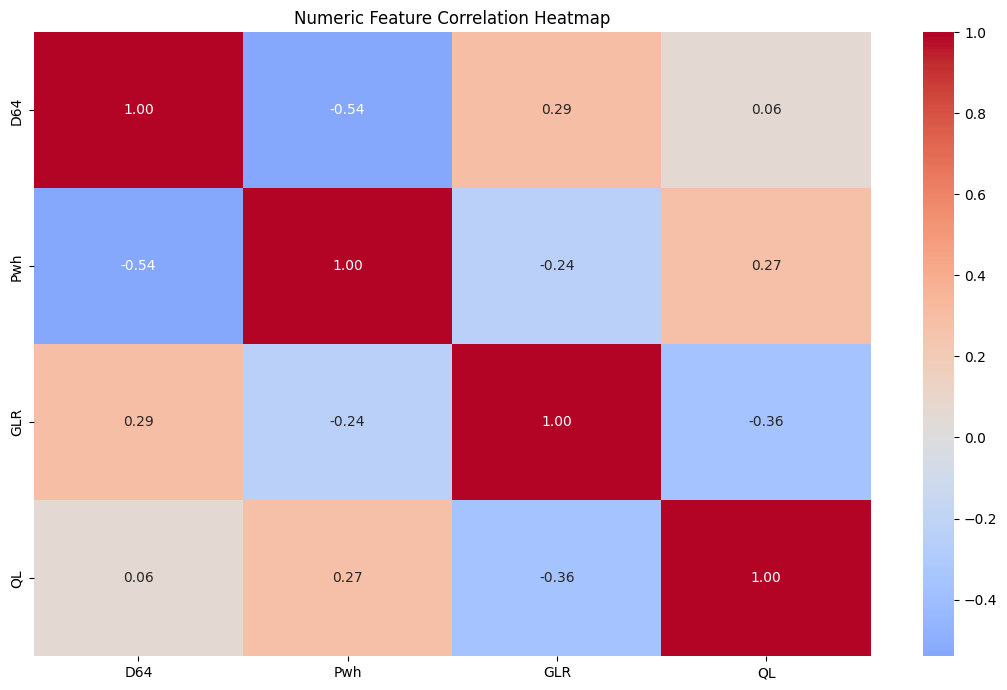

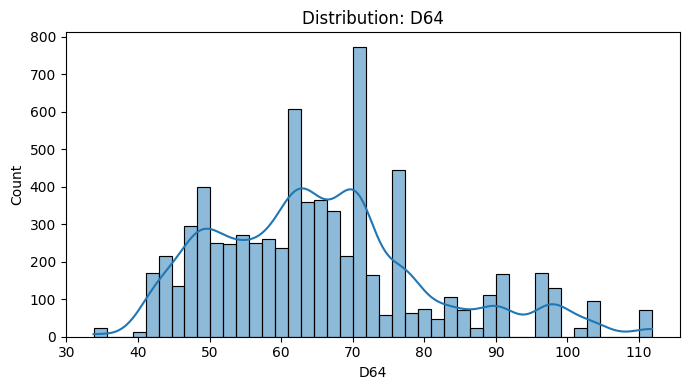

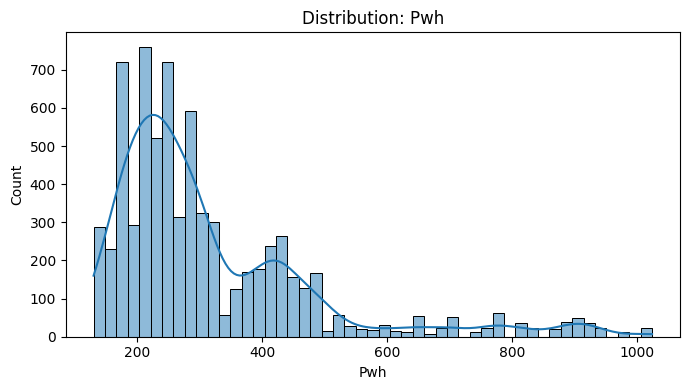

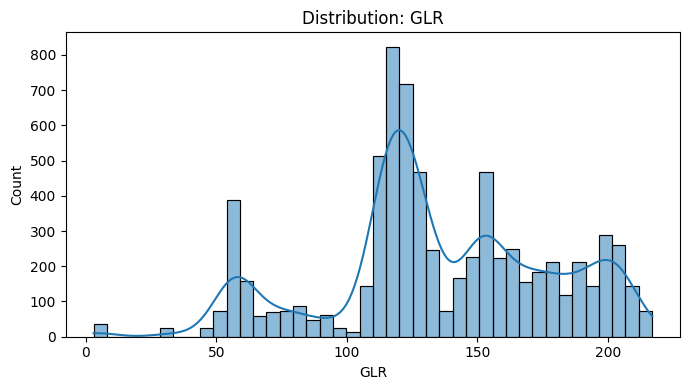

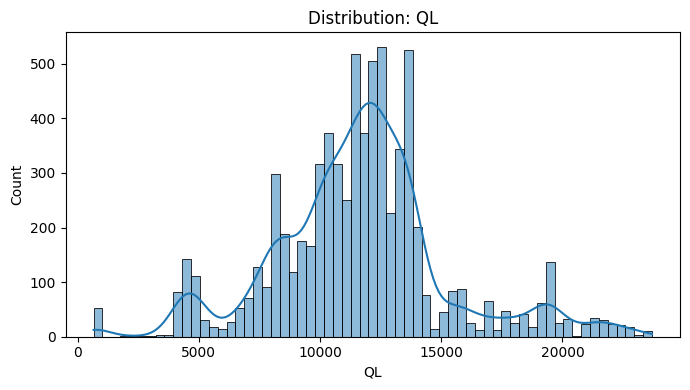

In [ ]:
# 4. EDA
numeric=raw.select_dtypes(include=[np.number]).copy()
numeric=numeric.drop(columns=["_original_row"],errors="ignore")
numeric=numeric.dropna(axis=1,how="all")

print("Numeric columns used in EDA:",list(numeric.columns))
display(numeric.describe().T)

if numeric.shape[1] >= 2:
    plt.figure(figsize=(11,7))
    corr=numeric.corr()
    sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=False)
    plt.title("Numeric Feature Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(ROOT/"figures"/"correlation_heatmap.png",dpi=180)
    plt.show()
else:
    raise RuntimeError("EDA found fewer than two valid numeric columns. Data loading is incorrect.")

for c in numeric.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(numeric[c].dropna(),kde=True)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.savefig(ROOT/"figures"/f"hist_{norm(c)}.png",dpi=150)
    plt.show()


# 5. Feature engineering

For the original dataset, the engineered variables follow the project methodology:

- ΔP = FWHP − CHK_DS
- Pdn/Pup = CHK_DS/FWHP
- Flow regime is classified as critical when Pdn/Pup ≤ 0.5
- WC = 100 − waterCut, following the definition used by the reference implementation
- ΔP/Pup
- Gross/FWHP as the pressure-normalized target

For the public replacement dataset, only variables that are actually available in the dataset are used.

In [ ]:
# 5. FEATURE ENGINEERING
df=raw.copy()

def resolve_col(df,candidates):
    ns={norm(c):c for c in df.columns}
    for x in candidates:
        if norm(x) in ns:
            return ns[norm(x)]
    return None

if DATA_MODE=="ORIGINAL_CS229":
    C={k:resolve_col(df,v) for k,v in ORIGINAL_ALIASES.items()}
    missing=[k for k,v in C.items() if v is None]
    if missing:
        raise RuntimeError(f"Original schema validation failed; missing: {missing}")

    for c in C.values():
        df[c]=pd.to_numeric(df[c],errors="coerce")

    df["DP"]=df[C["FWHP"]]-df[C["CHK_DS"]]
    df["Pdn_Pup"]=df[C["CHK_DS"]]/df[C["FWHP"]].replace(0,np.nan)
    df["FlowRegime"]=(df["Pdn_Pup"]<=0.5).astype(int)
    df["WC"]=100-df[C["waterCut"]]
    df["DP_over_Pup"]=df["DP"]/df[C["FWHP"]].replace(0,np.nan)
    df["PressureNormalizedTarget"]=df[C["Gross"]]/df[C["FWHP"]].replace(0,np.nan)

    PUP=C["FWHP"]
    TARGET_RAW=C["Gross"]
    TARGET_NORM="PressureNormalizedTarget"

    FEATURES_A=[
        PUP,C["GLR"],C["chokeSize"],C["Temp"],C["GOR"],
        "DP","WC","DP_over_Pup","FlowRegime"
    ]
    FEATURES_B=[
        C["GLR"],C["chokeSize"],C["Temp"],C["GOR"],
        "DP","WC","DP_over_Pup","FlowRegime"
    ]
    FEATURES_C=[
        C["GLR"],C["chokeSize"],C["Temp"],C["GOR"],"WC"
    ]

    print("Original feature engineering complete.")
    print("Model A:",FEATURES_A)
    print("Model B:",FEATURES_B)
    print("Model C:",FEATURES_C)
    print("Raw target:",TARGET_RAW)
    print("Normalized target:",TARGET_NORM)
else:
    C={"D64":"D64","Pwh":"Pwh","GLR":"GLR","QL":"QL"}
    for c in C.values():
        df[c]=pd.to_numeric(df[c],errors="coerce")

    df["PressureNormalizedTarget"]=df["QL"]/df["Pwh"].replace(0,np.nan)
    TARGET_RAW="QL"
    TARGET_NORM="PressureNormalizedTarget"

    FEATURES_A=["Pwh","D64","GLR"]
    FEATURES_B=["D64","GLR"]
    FEATURES_C=["D64","GLR"]

    print("Replacement feature engineering complete.")
    print("Model A:",FEATURES_A)
    print("Model B:",FEATURES_B)
    print("Model C:",FEATURES_C)
    print("Raw target:",TARGET_RAW)
    print("Normalized target:",TARGET_NORM)


Replacement feature engineering complete.
Model A: ['Pwh', 'D64', 'GLR']
Model B: ['D64', 'GLR']
Model C: ['D64', 'GLR']
Raw target: QL
Normalized target: PressureNormalizedTarget


# 6. Data cleaning and 3σ outlier removal

Records with invalid numerical values are removed. A three-standard-deviation filter is applied to the model features and raw liquid-rate target.

The pressure-normalized target is calculated after this filtering step and retained for the normalized-target analysis. Record counts before and after filtering are saved, together with feature-versus-target plots.

Rows: 7245 → valid: 7245 → 3σ clean: 6883
Normalized target: PressureNormalizedTarget
Normalized target present: True
Original row position preserved: True


,feature,mean,std,lower,upper
0,Pwh,318.513798,169.476577,-189.915934,826.943531
1,D64,65.700624,15.217598,20.047829,111.353420
2,GLR,135.325880,42.898960,6.629000,264.022760
3,QL,11666.705951,3624.781858,792.360377,22541.051525


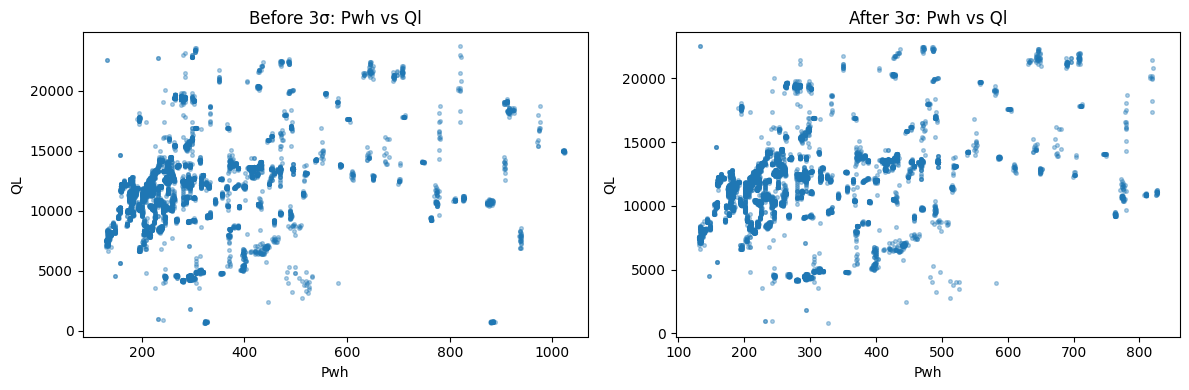

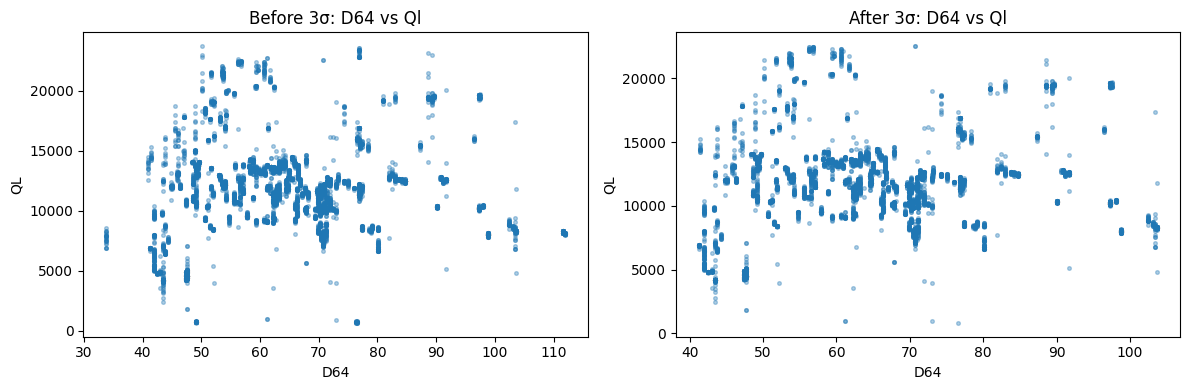

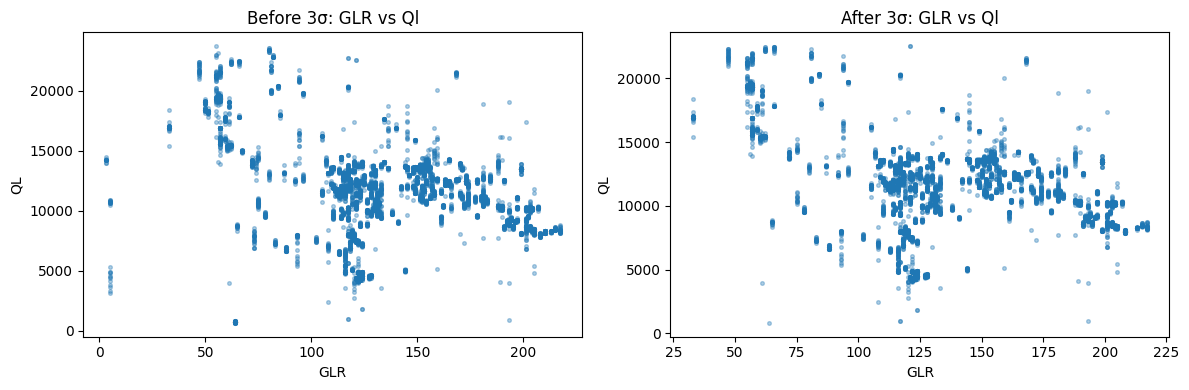

In [ ]:
# 6. CLEAN + 3 SIGMA
if DATA_MODE=="ORIGINAL_CS229":
    cleaning_features=list(dict.fromkeys(FEATURES_A))
    group_col=C["Group"]
else:
    cleaning_features=list(dict.fromkeys(FEATURES_A))
    group_col=None

# Keep the raw target and the columns required for the normalized target.
# Also preserve Group and original row position when available.
needed=cleaning_features+[TARGET_RAW]

if TARGET_NORM not in needed:
    if DATA_MODE=="ORIGINAL_CS229":
        needed += [C["FWHP"]]
    else:
        needed += [C["Pwh"]]

if group_col is not None:
    needed += [group_col]

if "_original_row" in df.columns:
    needed += ["_original_row"]

needed=list(dict.fromkeys(needed))

work=df[needed].copy()
before=len(work)

# Numeric conversion only for quantities used by the ML pipeline.
numeric_needed=list(dict.fromkeys(
    cleaning_features+[TARGET_RAW]+
    ([C["FWHP"]] if DATA_MODE=="ORIGINAL_CS229" else [C["Pwh"]])
))

for c in numeric_needed:
    work[c]=pd.to_numeric(work[c],errors="coerce")

work=work.replace([np.inf,-np.inf],np.nan)
work=work.dropna(subset=numeric_needed).copy()
after_valid=len(work)

# 3σ filtering is deliberately applied to the raw ML features + raw target.
# The normalized target is derived AFTER this filter.
threshold_rows=[]
mask=pd.Series(True,index=work.index)

for c in cleaning_features+[TARGET_RAW]:
    mu=work[c].mean()
    sd=work[c].std(ddof=1)
    lo=mu-3*sd
    hi=mu+3*sd

    threshold_rows.append({
        "feature":c,
        "mean":mu,
        "std":sd,
        "lower":lo,
        "upper":hi
    })

    mask &= work[c].between(lo,hi)

clean=work.loc[mask].copy()

# ------------------------------------------------------------
# IMPORTANT FIX:
# Build and PRESERVE the normalized target in clean.
#
# Original dataset:
#     normalized target = Gross / FWHP
#
# Public replacement:
#     normalized target = QL / Pwh
# ------------------------------------------------------------
if DATA_MODE=="ORIGINAL_CS229":
    clean[TARGET_NORM]=(
        clean[C["Gross"]] /
        clean[C["FWHP"]].replace(0,np.nan)
    )
else:
    clean[TARGET_NORM]=(
        clean["QL"] /
        clean["Pwh"].replace(0,np.nan)
    )

clean=clean.replace([np.inf,-np.inf],np.nan)
clean=clean.dropna(subset=[TARGET_NORM]).copy()

thresholds=pd.DataFrame(threshold_rows)

thresholds.to_csv(
    ROOT/"results"/"three_sigma_thresholds.csv",
    index=False
)

pd.DataFrame([{
    "raw_rows":before,
    "after_numeric_validation":after_valid,
    "after_3sigma":len(clean),
    "removed_total":before-len(clean),
    "removed_pct":100*(before-len(clean))/before
}]).to_csv(
    ROOT/"results"/"cleaning_counts.csv",
    index=False
)

clean.to_csv(
    ROOT/"results"/"clean_3sigma_dataset.csv",
    index=False
)

print(
    f"Rows: {before} → valid: {after_valid} "
    f"→ 3σ clean: {len(clean)}"
)
print("Normalized target:",TARGET_NORM)
print("Normalized target present:",TARGET_NORM in clean.columns)

if DATA_MODE=="ORIGINAL_CS229":
    print("Group column preserved:",group_col in clean.columns)
print("Original row position preserved:", "_original_row" in clean.columns)

display(thresholds)

# Before/after plots
for c in cleaning_features:
    fig,ax=plt.subplots(1,2,figsize=(12,4))

    ax[0].scatter(
        work[c],
        work[TARGET_RAW],
        s=7,
        alpha=.35
    )
    ax[0].set_title(f"Before 3σ: {c} vs Ql")

    ax[1].scatter(
        clean[c],
        clean[TARGET_RAW],
        s=7,
        alpha=.35
    )
    ax[1].set_title(f"After 3σ: {c} vs Ql")

    for a in ax:
        a.set_xlabel(c)
        a.set_ylabel(str(TARGET_RAW))

    plt.tight_layout()
    plt.savefig(
        ROOT/"figures"/
        f"before_after_3sigma_{norm(c)}.png",
        dpi=160
    )
    plt.show()


In [ ]:
# 6B. CLEAN-DATA INVARIANT CHECK
assert TARGET_NORM in clean.columns, (
    f"{TARGET_NORM} is missing from clean."
)

assert TARGET_RAW in clean.columns, (
    f"{TARGET_RAW} is missing from clean."
)

for feature in FEATURES_A + FEATURES_B + FEATURES_C:
    assert feature in clean.columns, (
        f"Required feature missing from clean: {feature}"
    )

if DATA_MODE=="ORIGINAL_CS229":
    assert group_col in clean.columns, (
        "Original Group column was not preserved through cleaning."
    )
    assert "_original_row" in clean.columns, (
        "Original row positions were not preserved."
    )

print("✓ Clean-data invariant passed.")
print("✓ Normalized target:",TARGET_NORM)
print("✓ Clean shape:",clean.shape)


✓ Clean-data invariant passed.
✓ Normalized target: PressureNormalizedTarget
✓ Clean shape: (6883, 6)


# 7. Gilbert correlation

A Gilbert-type empirical correlation is used as the physical baseline for comparison with the machine-learning models. Its predictions are evaluated against measured liquid rate using R², MAE, MSE, RMSE, correlation, and MAPE.

,Baseline,R2,MAE,MSE,RMSE,Correlation,MAPE_pct
0,Public-dataset adapted Gilbert-form baseline,-2.825535,6132.949612,4.396769e+07,6630.813629,0.675784,52.66456


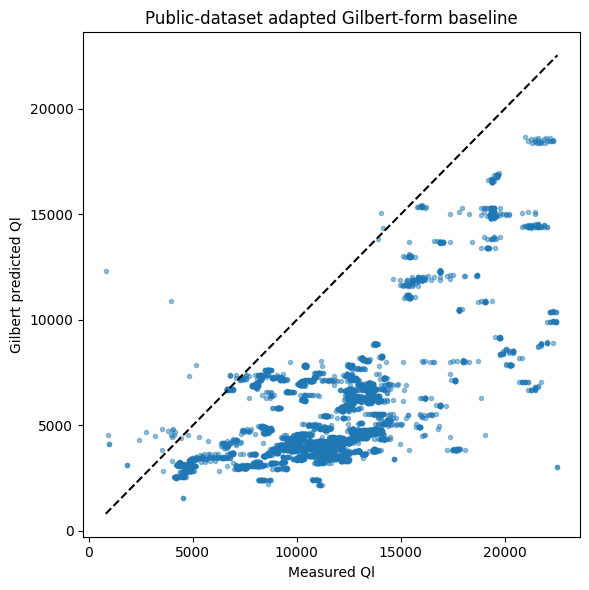

In [ ]:
# 7. METRICS + GILBERT
def metric_dict(y_true,y_pred):
    yt=np.asarray(y_true,dtype=float)
    yp=np.asarray(y_pred,dtype=float)
    mse=mean_squared_error(yt,yp)
    valid=yt!=0
    return {
        "R2":r2_score(yt,yp),
        "MAE":mean_absolute_error(yt,yp),
        "MSE":mse,
        "RMSE":math.sqrt(mse),
        "Correlation":np.corrcoef(yt,yp)[0,1] if len(yt)>1 else np.nan,
        "MAPE_pct":np.mean(np.abs((yt[valid]-yp[valid])/yt[valid]))*100 if valid.any() else np.nan
    }

if DATA_MODE=="ORIGINAL_CS229":
    gilbert_pred=(
        0.1*clean[C["FWHP"]]*clean[C["chokeSize"]]**1.89/
        clean[C["GLR"]]**0.546
    )
    gilbert_label="Original-schema Gilbert implementation"
else:
    gilbert_pred=(
        0.1*clean["Pwh"]*clean["D64"]**1.89/
        clean["GLR"]**0.546
    )
    gilbert_label="Public-dataset adapted Gilbert-form baseline"

gilbert_metrics=metric_dict(clean[TARGET_RAW],gilbert_pred)
gilbert_out=pd.DataFrame([gilbert_metrics])
gilbert_out.insert(0,"Baseline",gilbert_label)
display(gilbert_out)
gilbert_out.to_csv(ROOT/"results"/"gilbert_metrics.csv",index=False)

plt.figure(figsize=(6,6))
plt.scatter(clean[TARGET_RAW],gilbert_pred,s=9,alpha=.45)
lo=min(clean[TARGET_RAW].min(),np.nanmin(gilbert_pred))
hi=max(clean[TARGET_RAW].max(),np.nanmax(gilbert_pred))
plt.plot([lo,hi],[lo,hi],"k--")
plt.xlabel("Measured Ql")
plt.ylabel("Gilbert predicted Ql")
plt.title(gilbert_label)
plt.tight_layout()
plt.savefig(ROOT/"figures"/"gilbert_predicted_vs_measured.png",dpi=180)
plt.show()


# 8. Regression models

Ten regression models are evaluated:

1. Linear Regression
2. Ridge Regression
3. Bayesian Ridge
4. Polynomial Linear Regression
5. Polynomial Ridge Regression
6. MLP Regression
7. K-Nearest Neighbours
8. Random Forest
9. Gradient Tree Boosting
10. Extra Trees

Scaling is performed within the model pipelines so that the scaler is fitted using training data only.

In [ ]:
# 8. MODEL FACTORY
def make_models():
    return {
        "Linear Regression":Pipeline([
            ("scaler",StandardScaler()),
            ("model",LinearRegression())
        ]),
        "Ridge":Pipeline([
            ("scaler",StandardScaler()),
            ("model",Ridge(alpha=1.0))
        ]),
        "Bayesian Ridge":Pipeline([
            ("scaler",StandardScaler()),
            ("model",BayesianRidge())
        ]),
        "Polynomial Linear":Pipeline([
            ("poly",PolynomialFeatures(degree=2,include_bias=False)),
            ("scaler",StandardScaler()),
            ("model",LinearRegression())
        ]),
        "Polynomial Ridge":Pipeline([
            ("poly",PolynomialFeatures(degree=2,include_bias=False)),
            ("scaler",StandardScaler()),
            ("model",Ridge(alpha=1.0))
        ]),
        "MLP Regression":Pipeline([
            ("scaler",StandardScaler()),
            ("model",MLPRegressor(
                hidden_layer_sizes=(64,32),
                activation="relu",
                early_stopping=True,
                max_iter=1000,
                random_state=SEED
            ))
        ]),
        "KNN":Pipeline([
            ("scaler",StandardScaler()),
            ("model",KNeighborsRegressor(n_neighbors=7,weights="distance"))
        ]),
        "Random Forest":RandomForestRegressor(
            n_estimators=300,random_state=SEED,n_jobs=-1
        ),
        "Gradient Tree Boosting":GradientBoostingRegressor(
            n_estimators=300,random_state=SEED
        ),
        "Extra Trees":ExtraTreesRegressor(
            n_estimators=300,random_state=SEED,n_jobs=-1
        )
    }

MODEL_NAMES=list(make_models())
print(MODEL_NAMES)


['Linear Regression', 'Ridge', 'Bayesian Ridge', 'Polynomial Linear', 'Polynomial Ridge', 'MLP Regression', 'KNN', 'Random Forest', 'Gradient Tree Boosting', 'Extra Trees']


# 9. Data splitting

The initial model comparison uses an 80/20 train/test split. The later model-selection experiment uses an 80/10/10 train/test/validation split.

When field labels are available, the splits preserve the field distribution.

In [ ]:
# 9. SPLIT HELPERS
def get_group_series(frame):
    if DATA_MODE=="ORIGINAL_CS229":
        if group_col in frame.columns:
            return frame[group_col]
    return None


def split_80_20(X,y,groups=None):
    """
    Returns the actual index labels used for train/test.
    Keeping the indices lets us back-transform normalized predictions
    using exactly the same held-out rows.
    """
    if groups is not None and groups.nunique(dropna=True)>=2:
        train_idx,test_idx=train_test_split(
            X.index,
            test_size=.2,
            random_state=SEED,
            stratify=groups
        )
    else:
        train_idx,test_idx=train_test_split(
            X.index,
            test_size=.2,
            random_state=SEED
        )

    return (
        X.loc[train_idx],
        X.loc[test_idx],
        y.loc[train_idx],
        y.loc[test_idx],
        train_idx,
        test_idx
    )


def split_80_10_10(X,y,groups=None):
    if groups is not None and groups.nunique(dropna=True)>=2:
        Xtr,Xhold,ytr,yhold,gtr,ghold=train_test_split(
            X,y,groups,
            test_size=.2,
            random_state=SEED,
            stratify=groups
        )
        Xte,Xva,yte,yva=train_test_split(
            Xhold,yhold,
            test_size=.5,
            random_state=SEED,
            stratify=ghold
        )
    else:
        Xtr,Xhold,ytr,yhold=train_test_split(
            X,y,
            test_size=.2,
            random_state=SEED
        )
        Xte,Xva,yte,yva=train_test_split(
            Xhold,yhold,
            test_size=.5,
            random_state=SEED
        )

    return Xtr,Xte,Xva,ytr,yte,yva


# 10. Initial 80/20 model comparison

The ten regression models are trained using the initial feature set and evaluated on held-out test data. Predicted-versus-measured plots are generated for visual comparison.

,R2,MAE,MSE,RMSE,Correlation,MAPE_pct,Model,Target,Train_n,Test_n
0,0.953972,205.467052,4.982874e+05,705.894746,0.976776,2.654530,KNN,QL,5506,1377
1,0.943815,218.392249,6.082438e+05,779.899851,0.971573,2.785286,Random Forest,QL,5506,1377
2,0.936695,395.415703,6.853319e+05,827.847726,0.968149,4.249681,Gradient Tree Boosting,QL,5506,1377
3,0.927381,221.858268,7.861624e+05,886.657984,0.963281,2.776843,Extra Trees,QL,5506,1377
4,0.651262,1445.161496,3.775369e+06,1943.030774,0.807216,15.463334,Polynomial Linear,QL,5506,1377
5,0.650399,1443.860812,3.784711e+06,1945.433362,0.806843,15.523041,Polynomial Ridge,QL,5506,1377
6,0.395561,1995.179202,6.543526e+06,2558.031701,0.630922,21.886433,MLP Regression,QL,5506,1377
7,0.383851,1992.016347,6.670299e+06,2582.692290,0.620474,22.116747,Bayesian Ridge,QL,5506,1377
8,0.383840,1992.105129,6.670419e+06,2582.715349,0.620478,22.117096,Ridge,QL,5506,1377
9,0.383830,1992.188365,6.670531e+06,2582.737041,0.620481,22.117427,Linear Regression,QL,5506,1377


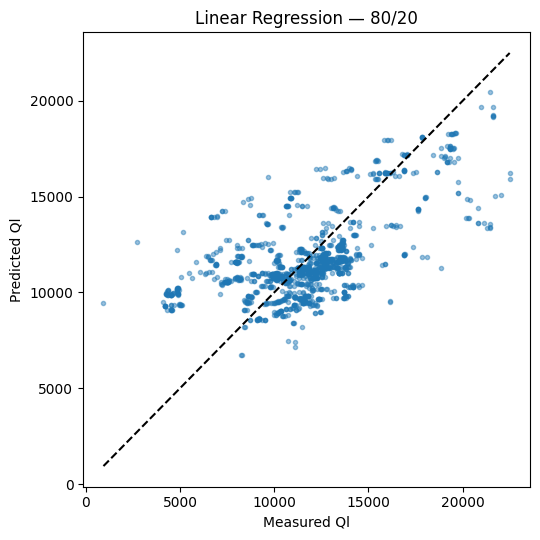

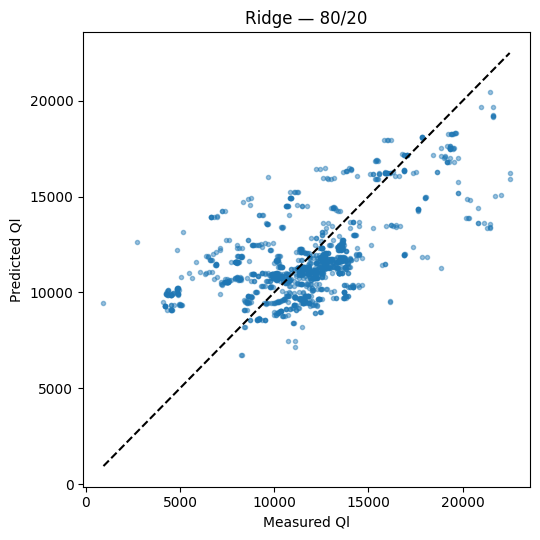

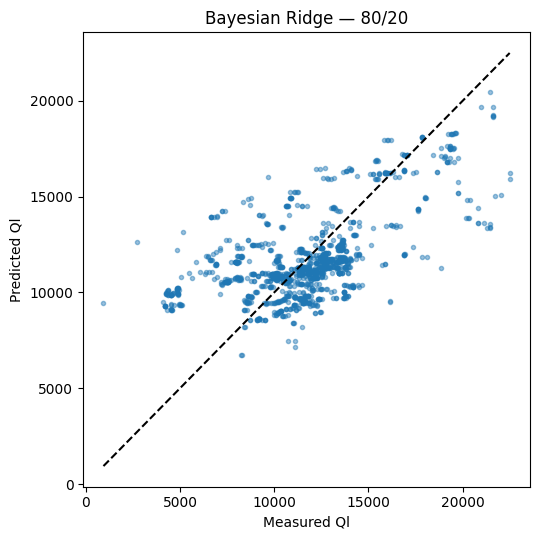

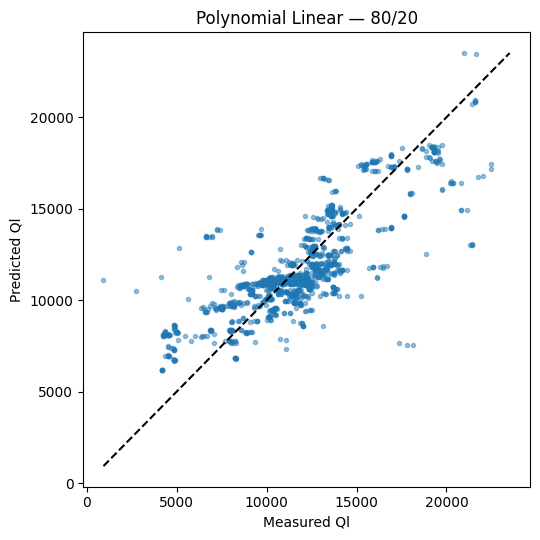

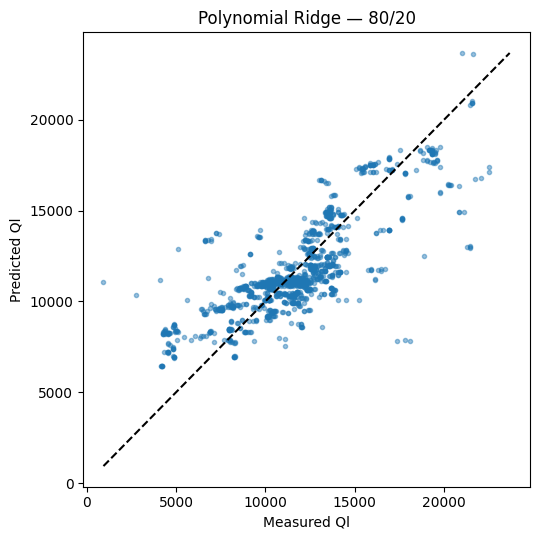

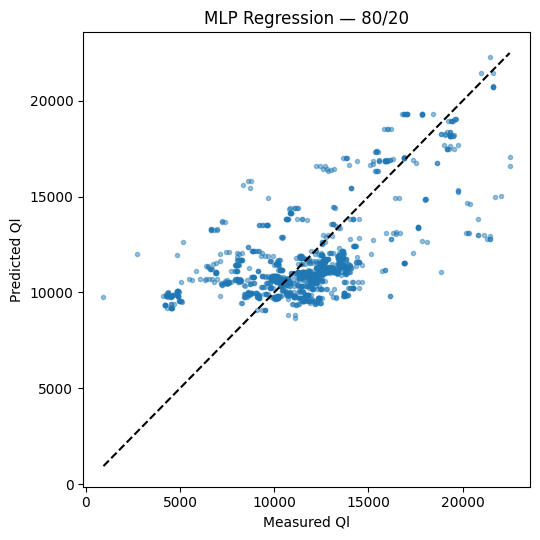

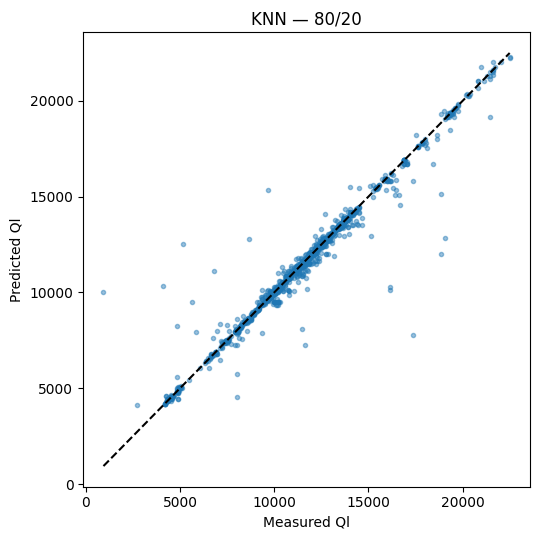

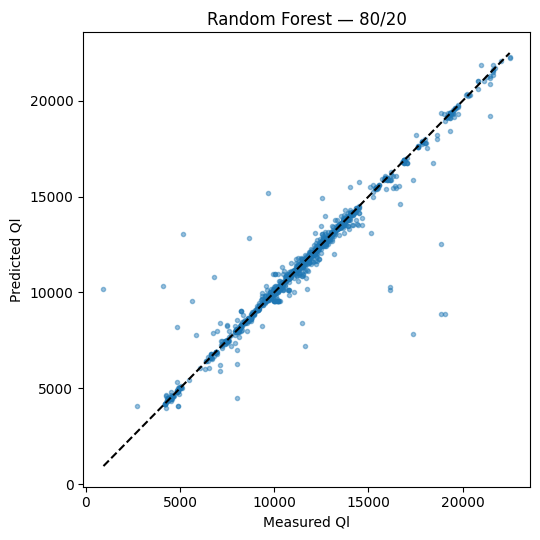

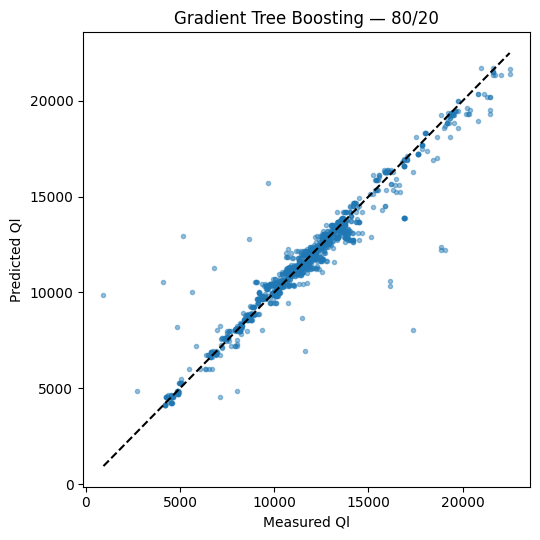

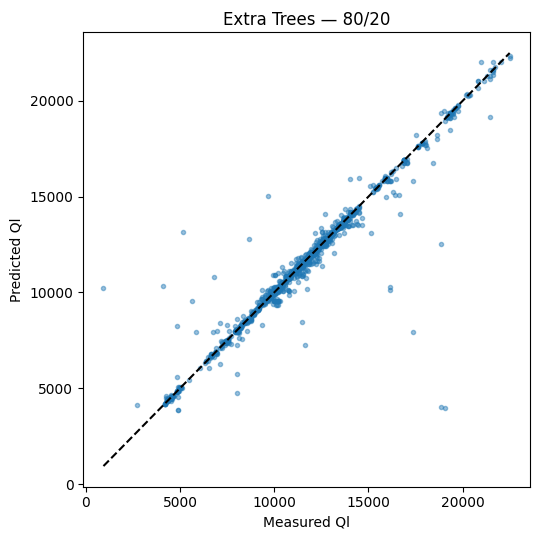

In [ ]:
Í# 10. INITIAL 80/20 SCREEN
def run_screen(frame,features,target):
    X=frame[features].copy()
    y=frame[target].copy()

    groups=get_group_series(frame)

    Xtr,Xte,ytr,yte,train_idx,test_idx=split_80_20(
        X,y,groups
    )

    rows=[]
    predictions={}
    fitted={}

    for name,model in make_models().items():
        model.fit(Xtr,ytr)

        pred=model.predict(Xte)

        m=metric_dict(yte,pred)
        m.update({
            "Model":name,
            "Target":target,
            "Train_n":len(Xtr),
            "Test_n":len(Xte)
        })

        rows.append(m)
        predictions[name]=(yte,pred)
        fitted[name]=model

    result=pd.DataFrame(rows).sort_values(
        "R2",
        ascending=False
    ).reset_index(drop=True)

    return (
        result,
        predictions,
        fitted,
        test_idx
    )


screen_results,screen_preds,screen_models,screen_test_idx=run_screen(
    clean,
    FEATURES_A,
    TARGET_RAW
)

display(screen_results)

screen_results.to_csv(
    ROOT/"results"/"initial_80_20_all10.csv",
    index=False
)

for name,(yt,yp) in screen_preds.items():
    plt.figure(figsize=(5.5,5.5))

    plt.scatter(
        yt,
        yp,
        s=9,
        alpha=.45
    )

    lo=min(yt.min(),yp.min())
    hi=max(yt.max(),yp.max())

    plt.plot(
        [lo,hi],
        [lo,hi],
        "k--"
    )

    plt.xlabel("Measured Ql")
    plt.ylabel("Predicted Ql")
    plt.title(f"{name} — 80/20")

    plt.tight_layout()

    plt.savefig(
        ROOT/"figures"/
        f"initial_{norm(name)}.png",
        dpi=150
    )

    plt.show()


# 11. Model A, Model B, and Model C

Three feature configurations are compared.

**Model A** uses the raw feature set, including upstream-pressure information.

**Model B** follows the paper-oriented approach by removing direct upstream pressure while retaining the specified derived pressure terms.

**Model C** provides a stricter test in which upstream-pressure-derived variables are removed where the available data allow this distinction.

In [ ]:
# 11. MODEL A/B/C COMPARISON
def compare_feature_sets(frame,target):
    all_rows=[]
    details={}

    sets={
        "Model A":FEATURES_A,
        "Model B":FEATURES_B,
        "Model C":FEATURES_C
    }

    for label,features in sets.items():
        res,preds,models,test_idx=run_screen(
            frame,
            features,
            target
        )

        res.insert(
            0,
            "FeatureSet",
            label
        )

        all_rows.append(res)

        details[label]={
            "results":res,
            "predictions":preds,
            "models":models,
            "test_idx":test_idx
        }

    return (
        pd.concat(
            all_rows,
            ignore_index=True
        ),
        details
    )


abc_results,abc_details=compare_feature_sets(
    clean,
    TARGET_RAW
)

display(
    abc_results.sort_values(
        ["FeatureSet","R2"],
        ascending=[True,False]
    )
)

abc_results.to_csv(
    ROOT/"results"/
    "model_A_B_C_raw_target.csv",
    index=False
)


,FeatureSet,R2,MAE,MSE,RMSE,Correlation,MAPE_pct,Model,Target,Train_n,Test_n
0,Model A,0.953972,205.467052,4.982874e+05,705.894746,0.976776,2.654530,KNN,QL,5506,1377
1,Model A,0.943815,218.392249,6.082438e+05,779.899851,0.971573,2.785286,Random Forest,QL,5506,1377
2,Model A,0.936695,395.415703,6.853319e+05,827.847726,0.968149,4.249681,Gradient Tree Boosting,QL,5506,1377
3,Model A,0.927381,221.858268,7.861624e+05,886.657984,0.963281,2.776843,Extra Trees,QL,5506,1377
4,Model A,0.651262,1445.161496,3.775369e+06,1943.030774,0.807216,15.463334,Polynomial Linear,QL,5506,1377
5,Model A,0.650399,1443.860812,3.784711e+06,1945.433362,0.806843,15.523041,Polynomial Ridge,QL,5506,1377
6,Model A,0.395561,1995.179202,6.543526e+06,2558.031701,0.630922,21.886433,MLP Regression,QL,5506,1377
7,Model A,0.383851,1992.016347,6.670299e+06,2582.692290,0.620474,22.116747,Bayesian Ridge,QL,5506,1377
8,Model A,0.383840,1992.105129,6.670419e+06,2582.715349,0.620478,22.117096,Ridge,QL,5506,1377
9,Model A,0.383830,1992.188365,6.670531e+06,2582.737041,0.620481,22.117427,Linear Regression,QL,5506,1377


# 12. Normalized target

The pressure-normalized target is evaluated separately from the raw liquid-rate target. For the original dataset, the normalized target is Gross/FWHP. Predictions from the Extra Trees model can subsequently be converted back to the original liquid-rate scale using FWHP.

In [ ]:
# 12. NORMALIZED TARGET SCREEN

# Defensive check: Step 6 should already have created this column.
if TARGET_NORM not in clean.columns:
    print(
        f"WARNING: {TARGET_NORM} was missing; "
        "rebuilding it defensively."
    )

    if DATA_MODE=="ORIGINAL_CS229":
        clean[TARGET_NORM]=(
            clean[C["Gross"]] /
            clean[C["FWHP"]].replace(0,np.nan)
        )
    else:
        clean[TARGET_NORM]=(
            clean["QL"] /
            clean["Pwh"].replace(0,np.nan)
        )

    clean=clean.replace(
        [np.inf,-np.inf],
        np.nan
    )

    clean=clean.dropna(
        subset=[TARGET_NORM]
    ).copy()

assert TARGET_NORM in clean.columns

print(
    "Running normalized-target screen on:",
    TARGET_NORM
)

norm_results,norm_preds,norm_models,norm_test_idx=run_screen(
    clean,
    FEATURES_B,
    TARGET_NORM
)

display(norm_results)

norm_results.to_csv(
    ROOT/"results"/
    "normalized_target_80_20.csv",
    index=False
)

# ------------------------------------------------------------
# BACK-TRANSFORMATION TO RAW Ql
#
# Original dataset:
#     normalized target = Gross / FWHP
#
# Therefore:
#     predicted Gross = predicted normalized target * FWHP
#
# The exact test indices returned by run_screen() are used.
# No second split is reconstructed.
# ------------------------------------------------------------
if DATA_MODE=="ORIGINAL_CS229":

    model=norm_models["Extra Trees"]

    pred_norm=model.predict(
        clean.loc[
            norm_test_idx,
            FEATURES_B
        ]
    )

    pup_hold=clean.loc[
        norm_test_idx,
        C["FWHP"]
    ].to_numpy()

    q_pred=pred_norm*pup_hold

    q_true=clean.loc[
        norm_test_idx,
        TARGET_RAW
    ].to_numpy()

    back_metrics=metric_dict(
        q_true,
        q_pred
    )

    print(
        "Extra Trees normalized-target "
        "predictions back-transformed to raw Ql:"
    )

    display(
        pd.DataFrame([back_metrics])
    )

    pd.DataFrame(
        [back_metrics]
    ).to_csv(
        ROOT/"results"/
        "normalized_ET_backtransformed_raw_scale.csv",
        index=False
    )

    plt.figure(figsize=(6,6))

    plt.scatter(
        q_true,
        q_pred,
        s=10,
        alpha=.5
    )

    lo=min(
        q_true.min(),
        q_pred.min()
    )
    hi=max(
        q_true.max(),
        q_pred.max()
    )

    plt.plot(
        [lo,hi],
        [lo,hi],
        "k--"
    )

    plt.xlabel("Measured Ql")
    plt.ylabel("Predicted Ql")
    plt.title(
        "Extra Trees — Normalized Target "
        "Back-Transformed to Ql"
    )

    plt.tight_layout()

    plt.savefig(
        ROOT/"figures"/
        "normalized_ET_backtransformed_predicted_vs_actual.png",
        dpi=170
    )

    plt.show()


Running normalized-target screen on: PressureNormalizedTarget


,R2,MAE,MSE,RMSE,Correlation,MAPE_pct,Model,Target,Train_n,Test_n
0,0.968349,0.948414,7.923814,2.814927,0.984070,3.305280,KNN,PressureNormalizedTarget,5506,1377
1,0.966997,0.952052,8.262335,2.874428,0.983401,3.258168,Random Forest,PressureNormalizedTarget,5506,1377
2,0.966863,0.952325,8.295867,2.880255,0.983336,3.259099,Extra Trees,PressureNormalizedTarget,5506,1377
3,0.949680,2.016642,12.597584,3.549308,0.974563,5.911258,Gradient Tree Boosting,PressureNormalizedTarget,5506,1377
4,0.812991,5.022215,46.818071,6.842373,0.901749,14.184195,MLP Regression,PressureNormalizedTarget,5506,1377
5,0.731607,6.070082,67.192791,8.197121,0.855568,17.536202,Polynomial Ridge,PressureNormalizedTarget,5506,1377
6,0.731516,6.070854,67.215527,8.198508,0.855547,17.511050,Polynomial Linear,PressureNormalizedTarget,5506,1377
7,0.465929,9.485035,133.705607,11.563114,0.682615,27.893708,Linear Regression,PressureNormalizedTarget,5506,1377
8,0.465929,9.485029,133.705659,11.563116,0.682616,27.895312,Ridge,PressureNormalizedTarget,5506,1377
9,0.465929,9.485023,133.705716,11.563119,0.682616,27.896789,Bayesian Ridge,PressureNormalizedTarget,5506,1377


# 13. Top-three model selection

The candidate models are evaluated using five-fold cross-validation on the training data. The three models with the highest mean cross-validated R² are selected for detailed evaluation.

In [ ]:
# 13. TOP-3 BY TRAIN-ONLY CV
X=clean[FEATURES_A].copy()
y=clean[TARGET_RAW].copy()
groups=get_group_series(clean)
X_train,X_test,X_val,y_train,y_test,y_val=split_80_10_10(X,y,groups)

cv=KFold(n_splits=5,shuffle=True,random_state=SEED)
cv_rows=[]
for name,model in make_models().items():
    scores=cross_val_score(
        model,X_train,y_train,
        cv=cv,scoring="r2",n_jobs=-1
    )
    cv_rows.append({
        "Model":name,
        "CV_R2_mean":scores.mean(),
        "CV_R2_std":scores.std()
    })

cv_results=pd.DataFrame(cv_rows).sort_values("CV_R2_mean",ascending=False).reset_index(drop=True)
top3=cv_results.head(3)["Model"].tolist()
display(cv_results)
print("TOP 3:",top3)
cv_results.to_csv(ROOT/"results"/"top3_train_only_cv.csv",index=False)


,Model,CV_R2_mean,CV_R2_std
0,Extra Trees,0.961575,0.015749
1,KNN,0.960948,0.017526
2,Random Forest,0.959699,0.016857
3,Gradient Tree Boosting,0.950392,0.015040
4,Polynomial Linear,0.660841,0.016437
5,Polynomial Ridge,0.660429,0.017864
6,MLP Regression,0.505693,0.098404
7,Bayesian Ridge,0.434841,0.030110
8,Ridge,0.434840,0.030114
9,Linear Regression,0.434839,0.030117


TOP 3: ['Extra Trees', 'KNN', 'Random Forest']


# 14. Top-three evaluation

The selected models are evaluated using the 80/10/10 train, test, and validation split. Performance is reported separately for each split using R², MAE, MSE, RMSE, correlation, and MAPE.

In [ ]:
# 14. TOP-3 80/10/10
top3_rows=[]
top3_models={}
top3_predictions={}

for name in top3:
    model=make_models()[name]
    model.fit(X_train,y_train)
    top3_models[name]=model

    for split,XX,yy in [
        ("train",X_train,y_train),
        ("test",X_test,y_test),
        ("validation",X_val,y_val)
    ]:
        pred=model.predict(XX)
        m=metric_dict(yy,pred)
        m.update({"Model":name,"Split":split})
        top3_rows.append(m)
        top3_predictions[(name,split)]=(yy,pred)

top3_eval=pd.DataFrame(top3_rows)
display(top3_eval)
top3_eval.to_csv(ROOT/"results"/"top3_80_10_10.csv",index=False)


,R2,MAE,MSE,RMSE,Correlation,MAPE_pct,Model,Split
0,0.983628,112.710754,190901.969917,436.923300,0.991780,1.291215,Extra Trees,train
1,0.920008,231.191262,809355.185781,899.641699,0.959508,3.624837,Extra Trees,test
2,0.933745,212.538821,763003.238538,873.500566,0.966605,1.930080,Extra Trees,validation
3,0.983031,115.306781,197863.138990,444.818097,0.991484,1.276045,KNN,train
4,0.950941,213.800146,496383.314089,704.544757,0.975181,3.480305,KNN,test
5,0.956566,197.146053,500188.707851,707.240205,0.978220,1.829954,KNN,validation
6,0.981622,132.612984,214282.492642,462.906570,0.990772,1.663208,Random Forest,train
7,0.936483,231.190971,642666.048972,801.664549,0.967818,3.661034,Random Forest,test
8,0.950168,205.612102,573871.465693,757.543045,0.974891,1.910809,Random Forest,validation


# 15. Extra Trees hyperparameter tuning

Extra Trees is tuned using RandomizedSearchCV. The search uses only the training data and five-fold cross-validation. The held-out test and validation sets are reserved for final evaluation.

In [ ]:
# 15. EXTRA TREES RANDOMIZED SEARCH
et=ExtraTreesRegressor(random_state=SEED,n_jobs=-1)
param_dist={
    "n_estimators":[200,400,600],
    "max_depth":[None,10,20,40],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":[1.0,"sqrt"]
}
search=RandomizedSearchCV(
    estimator=et,
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    return_train_score=True
)
search.fit(X_train,y_train)

print("Best CV R²:",search.best_score_)
print("Best parameters:")
print(search.best_params_)

tuned_ET=search.best_estimator_
tuned_rows=[]
for split,XX,yy in [
    ("train",X_train,y_train),
    ("test",X_test,y_test),
    ("validation",X_val,y_val)
]:
    pred=tuned_ET.predict(XX)
    m=metric_dict(yy,pred)
    m.update({"Model":"Tuned Extra Trees","Split":split})
    tuned_rows.append(m)

tuned_eval=pd.DataFrame(tuned_rows)
display(tuned_eval)
tuned_eval.to_csv(ROOT/"results"/"tuned_extra_trees_metrics.csv",index=False)
joblib.dump(tuned_ET,ROOT/"models"/"tuned_extra_trees.joblib")


Best CV R²: 0.9625114785374986
Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 40}


,R2,MAE,MSE,RMSE,Correlation,MAPE_pct,Model,Split
0,0.973154,160.879411,313029.285909,559.490202,0.986488,2.170563,Tuned Extra Trees,train
1,0.948751,220.248036,518540.941612,720.097869,0.974067,3.584784,Tuned Extra Trees,test
2,0.963289,191.684634,422769.727390,650.207450,0.981583,1.854345,Tuned Extra Trees,validation


['/content/wellhead_choke_phase1_12_project/models/tuned_extra_trees.joblib']

# 16. Model diagnostics

The tuned Extra Trees model is examined using predicted-versus-measured plots, residual plots, residual distributions, absolute-error distributions, and feature importance.

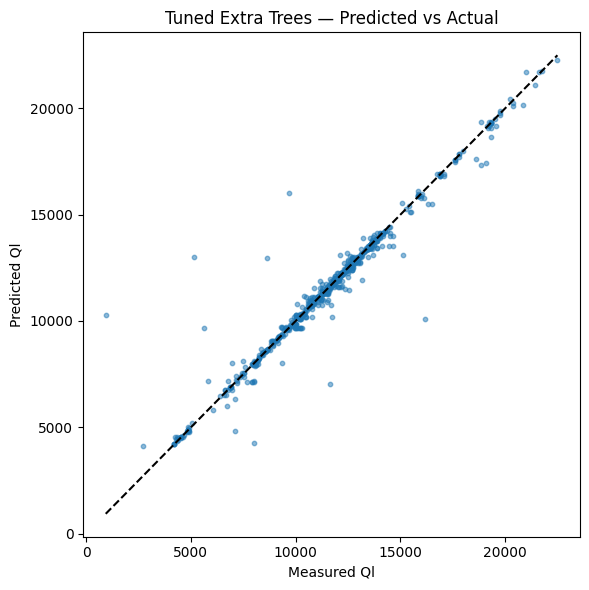

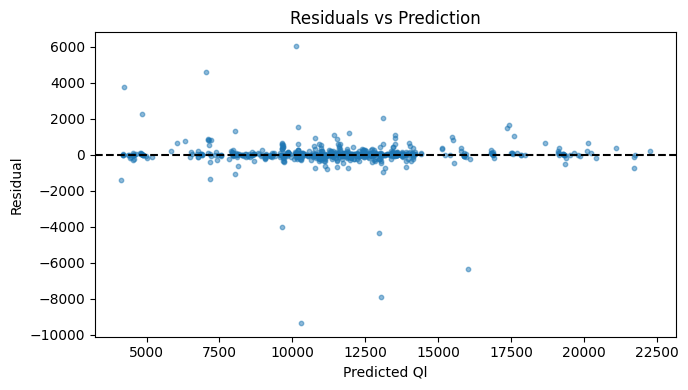

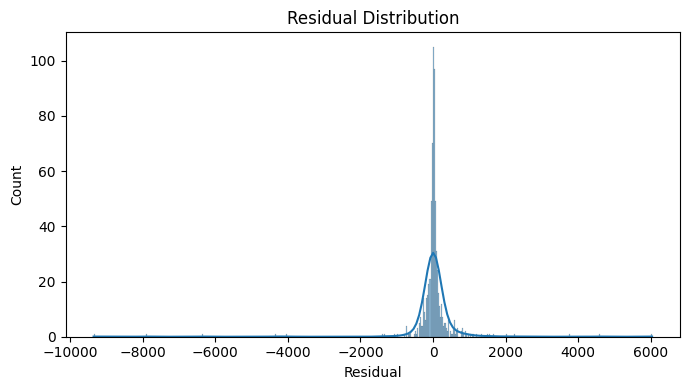

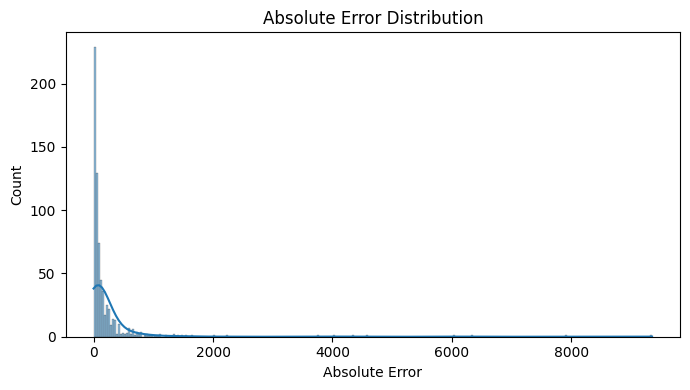

,importance
GLR,0.453755
D64,0.320018
Pwh,0.226227


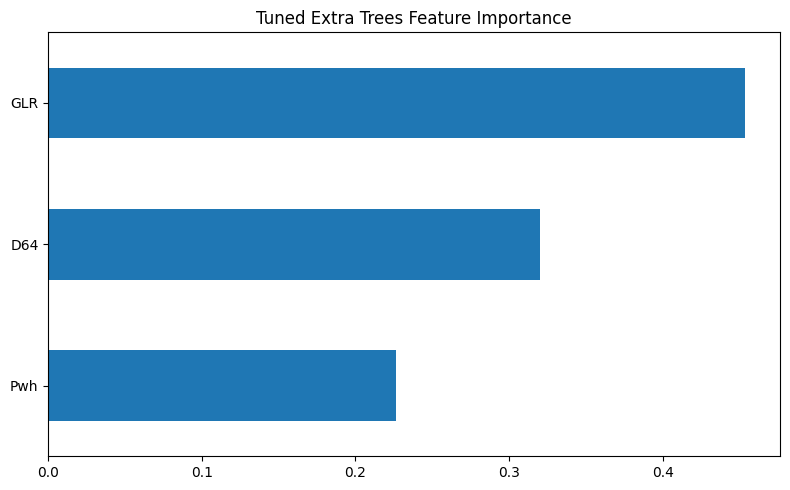

In [ ]:
# 16. DIAGNOSTICS
pred_test=tuned_ET.predict(X_test)
residual=y_test.to_numpy()-pred_test

plt.figure(figsize=(6,6))
plt.scatter(y_test,pred_test,s=10,alpha=.5)
lo=min(y_test.min(),pred_test.min()); hi=max(y_test.max(),pred_test.max())
plt.plot([lo,hi],[lo,hi],"k--")
plt.xlabel("Measured Ql"); plt.ylabel("Predicted Ql")
plt.title("Tuned Extra Trees — Predicted vs Actual")
plt.tight_layout(); plt.savefig(ROOT/"figures"/"tuned_ET_predicted_vs_actual.png",dpi=180); plt.show()

plt.figure(figsize=(7,4))
plt.scatter(pred_test,residual,s=10,alpha=.5)
plt.axhline(0,ls="--",color="black")
plt.xlabel("Predicted Ql"); plt.ylabel("Residual")
plt.title("Residuals vs Prediction")
plt.tight_layout(); plt.savefig(ROOT/"figures"/"residuals_vs_prediction.png",dpi=180); plt.show()

plt.figure(figsize=(7,4))
sns.histplot(residual,kde=True)
plt.xlabel("Residual"); plt.title("Residual Distribution")
plt.tight_layout(); plt.savefig(ROOT/"figures"/"residual_distribution.png",dpi=180); plt.show()

plt.figure(figsize=(7,4))
sns.histplot(np.abs(residual),kde=True)
plt.xlabel("Absolute Error"); plt.title("Absolute Error Distribution")
plt.tight_layout(); plt.savefig(ROOT/"figures"/"absolute_error_distribution.png",dpi=180); plt.show()

if hasattr(tuned_ET,"feature_importances_"):
    importance=pd.Series(
        tuned_ET.feature_importances_,index=FEATURES_A
    ).sort_values(ascending=False)
    display(importance.to_frame("importance"))
    importance.to_csv(ROOT/"results"/"feature_importance.csv")
    plt.figure(figsize=(8,5))
    importance.sort_values().plot(kind="barh")
    plt.title("Tuned Extra Trees Feature Importance")
    plt.tight_layout(); plt.savefig(ROOT/"figures"/"feature_importance.png",dpi=180); plt.show()


# 17. Field analysis

When the original field information is available, the analysis is performed for the complete dataset and separately for Fields A+C and Field B.

Field assignment follows the available Group information or the documented original row ordering.

In [ ]:
# 17. FIELD ANALYSIS
def assign_original_fields(frame):
    if DATA_MODE!="ORIGINAL_CS229":
        return None,"not applicable"

    if group_col in frame.columns:
        g=frame[group_col].astype(str).str.strip().str.upper()
        vals=set(g.dropna().unique())

        if {"A","B","C"}.issubset(vals):
            return g,"explicit Group labels"

    # Use original row position from the unfiltered source.
    if "_original_row" in frame.columns:
        pos=frame["_original_row"]

        label=pd.Series(
            index=frame.index,
            dtype="object"
        )

        label[pos.between(
            0,1488,
            inclusive="both"
        )]="A"

        label[pos.between(
            1489,3058,
            inclusive="both"
        )]="B"

        label[pos>=3059]="C"

        if label.notna().any():
            return label,"documented original row positions"

    return None,"insufficient evidence"


field_labels,evidence=assign_original_fields(clean)

if field_labels is None:
    print(
        "Field A+C vs B not run:",
        evidence
    )
else:
    print(
        "Field evidence:",
        evidence
    )

    for subset_name,mask in {
        "All fields":pd.Series(
            True,
            index=clean.index
        ),
        "A+C":field_labels.isin(["A","C"]),
        "B":field_labels.eq("B")
    }.items():

        sub=clean.loc[mask].copy()

        if len(sub)<20:
            print(
                "Skipping",
                subset_name,
                "— too few rows:",
                len(sub)
            )
            continue

        res,_,_,field_test_idx=run_screen(
            sub,
            FEATURES_A,
            TARGET_RAW
        )

        res.insert(
            0,
            "FieldSubset",
            subset_name
        )

        display(res)

        res.to_csv(
            ROOT/"results"/
            f"field_{norm(subset_name)}_80_20.csv",
            index=False
        )


Field A+C vs B not run: not applicable


# 18. Saving the results

The trained models, search results, metrics, figures, cleaned datasets, and run information are saved in the project directories for use in the report.

In [ ]:
# 18. SAVE EVERYTHING
for name,model in top3_models.items():
    joblib.dump(model,ROOT/"models"/f"top3_{norm(name)}.joblib")
joblib.dump(search,ROOT/"models"/"extra_trees_randomized_search.joblib")

manifest={
    "seed":SEED,
    "data_mode":DATA_MODE,
    "rows_loaded":int(len(raw)),
    "rows_after_3sigma":int(len(clean)),
    "target_raw":str(TARGET_RAW),
    "target_normalized":str(TARGET_NORM),
    "features_A":list(FEATURES_A),
    "features_B":list(FEATURES_B),
    "features_C":list(FEATURES_C),
    "top3_by_train_only_cv":top3,
    "extra_trees_best_params":search.best_params_,
    "field_evidence":evidence,
    "field_analysis_run":("field_labels" in globals() and field_labels is not None),
    "replacement_warning":(
        DATA_MODE=="PUBLIC_REPLACEMENT"
    )
}
(ROOT/"results"/"run_manifest.json").write_text(
    json.dumps(manifest,indent=2,default=str),
    encoding="utf-8"
)
print(json.dumps(manifest,indent=2,default=str))


{
  "seed": 42,
  "data_mode": "PUBLIC_REPLACEMENT",
  "rows_loaded": 7245,
  "rows_after_3sigma": 6883,
  "target_raw": "QL",
  "target_normalized": "PressureNormalizedTarget",
  "features_A": [
    "Pwh",
    "D64",
    "GLR"
  ],
  "features_B": [
    "D64",
    "GLR"
  ],
  "features_C": [
    "D64",
    "GLR"
  ],
  "top3_by_train_only_cv": [
    "Extra Trees",
    "KNN",
    "Random Forest"
  ],
  "extra_trees_best_params": {
    "n_estimators": 200,
    "min_samples_split": 10,
    "min_samples_leaf": 2,
    "max_features": 1.0,
    "max_depth": 40
  },
  "field_evidence": "not applicable",
  "field_analysis_run": false,
  "replacement_warning": true
}


# 19. Project outputs

The generated files include model-comparison tables, normalized-target results, Extra Trees tuning results, diagnostic plots, cleaned datasets, and field-level results when applicable.

# 20. Reproducibility

All experiments use the fixed random seed of 42. The notebook records the dataset, row counts, feature sets, selected models, and Extra Trees parameters so that the analysis can be reproduced.